In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("ds_salaries.csv")
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [5]:
data.shape


(607, 12)

In [6]:
data.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [9]:
data['experience_level'].value_counts()

experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64

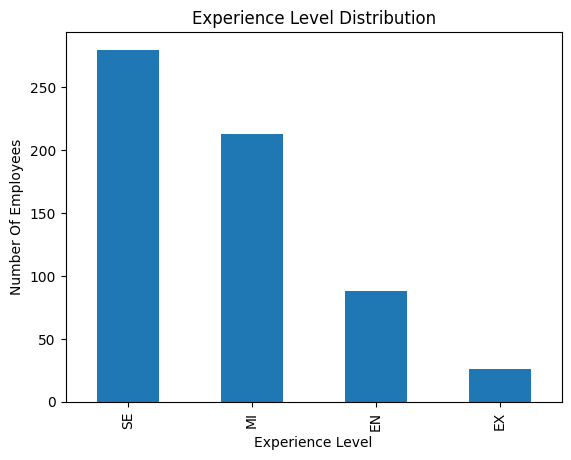

In [10]:
data['experience_level'].value_counts().plot(kind='bar')
plt.title("Experience Level Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Number Of Employees")
plt.show()

In [12]:
data['job_title'].value_counts().head(10)

job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Director of Data Science        7
Name: count, dtype: int64

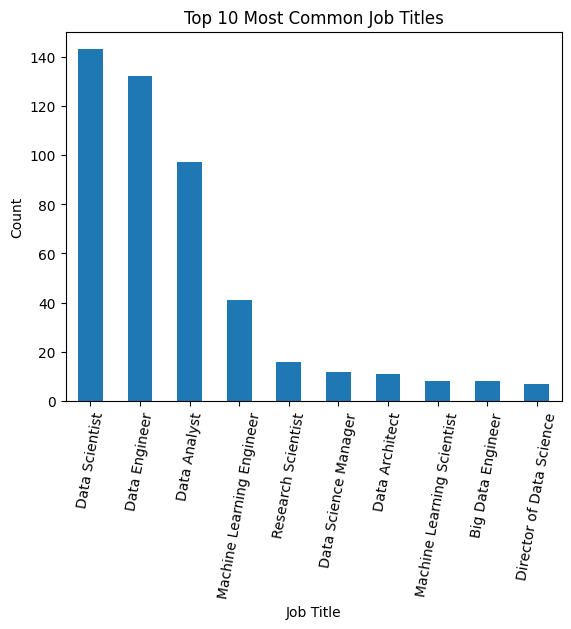

In [17]:
data['job_title'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=80)
plt.show()

In [18]:
data.groupby('experience_level')['salary_in_usd'].mean()

experience_level
EN     61643.318182
EX    199392.038462
MI     87996.056338
SE    138617.292857
Name: salary_in_usd, dtype: float64

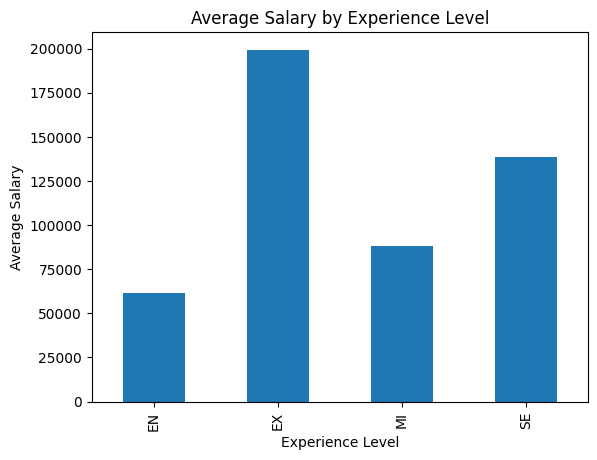

In [19]:
data.groupby('experience_level')['salary_in_usd'].mean().plot(kind='bar')
plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")
plt.show()

In [21]:
data.groupby('work_year')['salary_in_usd'].mean()

work_year
2020     95813.000000
2021     99853.792627
2022    124522.006289
Name: salary_in_usd, dtype: float64

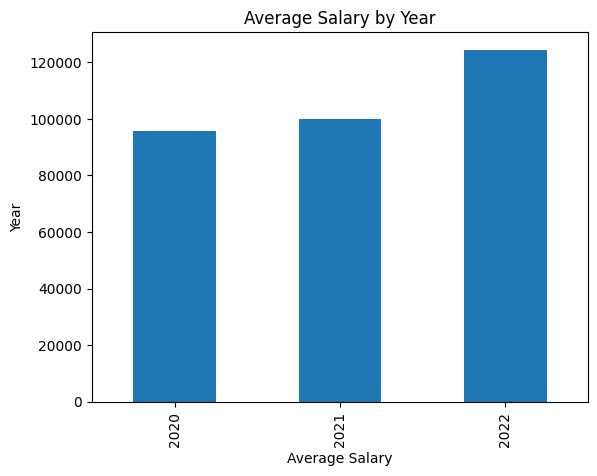

In [22]:
data.groupby('work_year')['salary_in_usd'].mean().plot(kind='bar')
plt.title("Average Salary by Year")
plt.xlabel("Average Salary")
plt.ylabel("Year")
plt.show()

In [26]:
data['remote_ratio'].value_counts()

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64

In [30]:
data['company_location'].value_counts(10).head(10)

company_location
US    0.584843
GB    0.077430
CA    0.049423
DE    0.046129
IN    0.039539
FR    0.024712
ES    0.023064
GR    0.018122
JP    0.009885
NL    0.006590
Name: proportion, dtype: float64

In [51]:
data=data.drop(columns=['Unnamed: 0'])

In [54]:
X=data.drop('salary_in_usd',axis=1)
y=data['salary_in_usd']

In [55]:
X.dtypes


work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [56]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
categorical_columns=X.select_dtypes(include=['object']).columns

In [57]:
for column in categorical_columns:
    X[column]=le.fit_transform(X[column])

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE:",mean_absolute_error(y_test,y_pred_dt))
print("MsE:",mean_squared_error(y_test,y_pred_dt))
print("R2Score:",r2_score(y_test,y_pred_dt))

MAE: 6282.918032786885
MsE: 434350977.1967213
R2Score: 0.8866684573233345


In [62]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

In [63]:
print("MAE:",mean_absolute_error(y_test,y_pred_rf))
print("MsE:",mean_squared_error(y_test,y_pred_rf))
print("R2Score:",r2_score(y_test,y_pred_rf))

MAE: 4867.960737704918
MsE: 186438124.93864834
R2Score: 0.9513542701125954


In [69]:
data.to_csv("Cleaned_job_Market.csv",index=False)

In [67]:
!pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import os
print(os.getcwd())

C:\Users\alenc


In [72]:
data.to_csv("Cleaned_job_Market.csv",index=False)

In [73]:
import os
print(os.listdir())

['.anaconda', '.bash_history', '.conda', '.condarc', '.continuum', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.streamlit', '.vscode', 'Alen Oct Python.ipynb', 'anaconda3', 'anaconda_projects', 'ansel', 'AppData', 'Application Data', 'Assignment 1.ipynb', 'Assignment.ipynb', 'churn_model.pkl', 'Cleaned_job_Market.csv', 'Contacts', 'Cookies', 'Customer Churn Data.csv', 'Customer Churn Prediction.ipynb', 'Customer_Churn_Cleaned.xlsx', 'Desktop', 'Documents', 'document_assistant', 'Downloads', 'ds_salaries.csv', 'End to End market Analytics.ipynb', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.0.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.1.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.2.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3